# U.S. Flight Delay Analysis & Prediction

**Objective.** Predict whether a scheduled U.S. flight will arrive at least 15 minutes late, while keeping the model useful for an operational decision and avoiding post-outcome leakage.

**Analysis period:** 2024–2025  
**Primary target:** `ArrDel15 = 1`  
**Primary model-selection metric:** PR-AUC

## Executive summary

The goal is to identify flights at risk of arriving at least 15 minutes late using only information available **two hours before departure**.

A schedule-only model provides useful but limited signal. The largest gains came from adding information that reflects current operating conditions: first the **inbound aircraft state**, then **recent origin weather**. Aircraft metadata added a smaller improvement.

The final model reached **ROC-AUC 0.7369 / PR-AUC 0.4807** on validation and **ROC-AUC 0.7417 / PR-AUC 0.4941** on the held-out Jul-Dec 2025 test period. In the final test, **60.11% of the highest-risk 10% of flights were actually delayed**, capturing **26.47% of all delayed flights**.

## 1. Problem framing

The best prediction time depends on how the model will be used.

For passengers, predictions further in advance are useful because people need time to change plans. For airline operations, predictions closer to departure can use more current information.

This analysis focuses on an **airline operations use case** and predicts at **two hours before scheduled departure (T-2h)**. This gives the airline time to act while allowing us to use recent weather and inbound aircraft status.

> **At T-2h, which operating flights are most likely to arrive at least 15 minutes late?**

Cancelled and diverted flights are excluded because they are different disruption outcomes and should be modeled separately.

## 2. Data

| Source | Role |
|---|---|
| BTS Reporting Carrier On-Time Performance, 2024–2025 | Flight schedule, actual operations, target, delay causes |
| FAA Aircraft Registration Database | Aircraft model, manufacture year, seating capacity |
| Iowa Environmental Mesonet ASOS/METAR archive | Recent origin weather available by T−2h |

The BTS data contain roughly **14.1M scheduled flights** across 2024–2025. The normal-arrival population contains about **13.84M completed, non-diverted flights**.

Current FAA ownership/status fields are intentionally not used because the registry is a current snapshot, while aircraft model and manufacture year are essentially static.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format
PROJECT_ROOT = Path("..")
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

## 3. Data quality and missing values

Missing values are handled based on what they mean.

- **Cancelled/diverted flights:** operational fields are often missing because the flight did not operate normally. These values are not imputed.
- **Target:** only completed, non-diverted flights with a valid arrival outcome are used.
- **Invalid scheduled duration:** a very small number of missing or non-positive values are removed.
- **Delay causes:** used only for EDA because they are known after the outcome.
- **Aircraft:** missing model is labeled `Unknown`; age and seats are median-imputed.
- **Weather:** numeric fields are median-imputed. A `gust_reported` flag is also kept.

In [ ]:
# Check duplicates
flight_key = [
    "FlightDate",
    "Reporting_Airline",
    "Flight_Number_Reporting_Airline",
    "Origin",
    "Dest"
]

flights.duplicated(subset=flight_key).sum()

np.int64(0)

In [ ]:
flights[["Cancelled", "Diverted"]].value_counts()

Cancelled  Diverted
0.00       0.00        13844732
1.00       0.00          199191
0.00       1.00           36757
Name: count, dtype: int64

In [ ]:
flights[[
    "ArrDelay",
    "DepDelay",
    "TaxiOut",
    "TaxiIn",
    "CRSElapsedTime",
    "ActualElapsedTime",
    "AirTime",
    "Distance"
]].describe(percentiles=[.01, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,25%,50%,75%,95%,99%,max
ArrDelay,"13,844,731.00",7.80,58.87,-128.00,-37.00,-15.00,-6.00,10.00,87.00,220.00,"4,336.00"
DepDelay,"13,889,119.00",13.11,56.80,-115.00,-14.00,-6.00,-2.00,10.00,87.00,221.00,"4,352.00"
TaxiOut,"13,882,763.00",18.27,10.21,1.00,7.00,12.00,16.00,21.00,36.00,58.00,"1,274.00"
TaxiIn,"13,878,216.00",8.47,7.10,1.00,2.00,5.00,6.00,10.00,20.00,37.00,"1,318.00"
CRSElapsedTime,"14,080,677.00",147.83,72.68,-160.00,50.00,95.00,131.00,179.00,306.00,375.00,"1,510.00"
ActualElapsedTime,"13,844,731.00",142.64,72.79,15.00,45.00,89.00,126.00,174.00,299.00,369.00,965.00
AirTime,"13,844,731.00",115.92,70.82,5.00,24.00,64.00,99.00,146.00,270.00,335.00,953.00
Distance,"14,080,680.00",839.15,599.13,11.00,100.00,402.00,689.00,"1,073.00","2,177.00","2,611.00","5,095.00"


## 4. Exploratory findings

EDA was used to understand when delays happen and to guide feature design.

- About **22%** of completed flights are delayed at least 15 minutes.
- Delay risk is higher in summer, especially around July.
- Delay risk rises through the day, from roughly 10% early in the morning to around 30% in the evening.
- Late inbound aircraft become much more common later in the day. This led to the inbound-aircraft feature.
- Airports, airlines and routes show different delay rates, but these are descriptive patterns rather than causal rankings.

In [ ]:
delay_summary = pd.Series({
    "Total completed flights": f"{len(completed_flights):,}",
    "Delay rate (>=15 min)": f"{completed_flights['ArrDel15'].mean():.1%}",
    "Average arrival delay": f"{completed_flights['ArrDelay'].mean():.1f} min",
    "Median arrival delay": f"{completed_flights['ArrDelay'].median():.1f} min",
    "90th percentile": f"{completed_flights['ArrDelay'].quantile(.90):.0f} min",
    "95th percentile": f"{completed_flights['ArrDelay'].quantile(.95):.0f} min",
    "99th percentile": f"{completed_flights['ArrDelay'].quantile(.99):.0f} min",
})

delay_summary

Total completed flights    13,844,731
Delay rate (>=15 min)           21.6%
Average arrival delay         7.8 min
Median arrival delay         -6.0 min
90th percentile                46 min
95th percentile                87 min
99th percentile               220 min
dtype: object

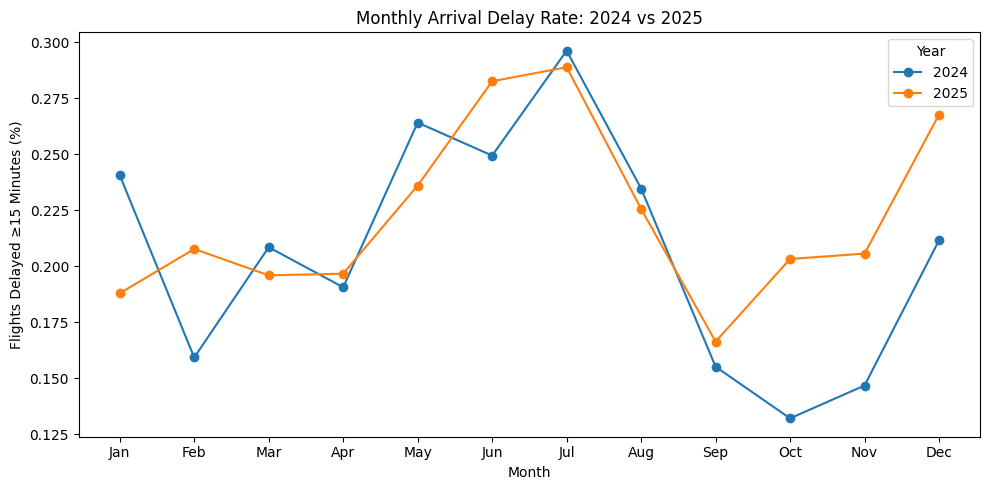

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

for year, group in monthly_delay.groupby("Year"):
    ax.plot(
        group["Month"],
        group["delay_rate"],
        marker="o",
        label=str(year)
    )

ax.set_title("Monthly Arrival Delay Rate: 2024 vs 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Flights Delayed ≥15 Minutes (%)")

ax.set_xticks(range(1, 13))
ax.set_xticklabels([
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
])

ax.legend(title="Year")

plt.tight_layout()
plt.show()

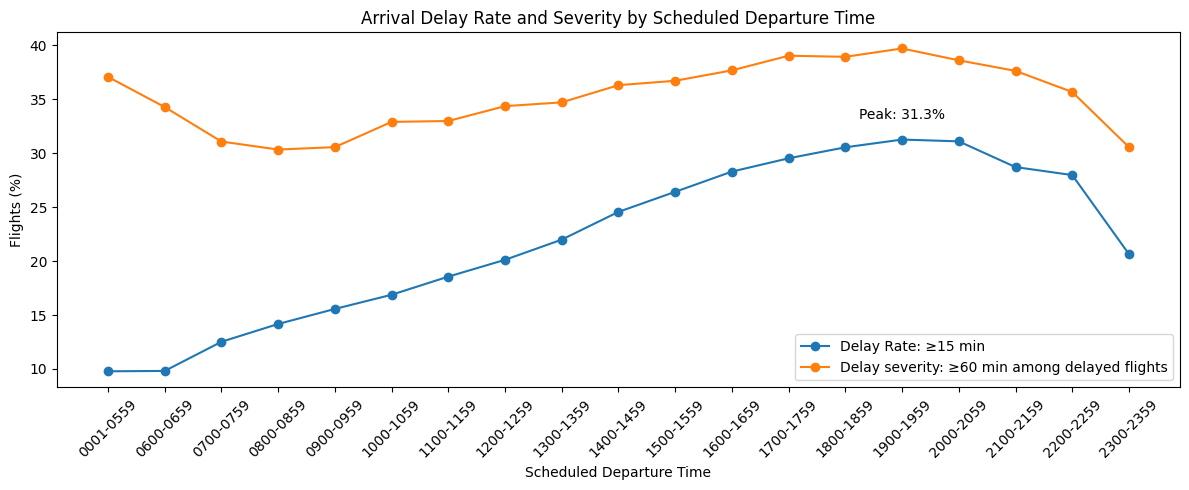

In [ ]:
time_frequency = (
    completed_flights
    .groupby("DepTimeBlk")
    .agg(
        flights=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean")
    )
)

time_severity = (
    completed_flights[
        completed_flights["ArrDel15"] == 1
    ]
    .assign(
        severe_delay=lambda x: x["ArrDelay"] >= 60
    )
    .groupby("DepTimeBlk")
    .agg(
        severe_given_delayed=("severe_delay", "mean")
    )
)

time_delay = (
    time_frequency
    .join(time_severity)
    .reset_index()
)

time_delay["delay_rate"] *= 100
time_delay["severe_given_delayed"] *= 100

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    time_delay["DepTimeBlk"],
    time_delay["delay_rate"],
    marker="o",
    label="Delay Rate: ≥15 min"
)

ax.plot(
    time_delay["DepTimeBlk"],
    time_delay["severe_given_delayed"],
    marker="o",
    label="Delay severity: ≥60 min among delayed flights"
)

ax.set_title("Arrival Delay Rate and Severity by Scheduled Departure Time")
ax.set_xlabel("Scheduled Departure Time")
ax.set_ylabel("Flights (%)")

ax.tick_params(axis="x", rotation=45)
ax.legend()

peak = time_delay.loc[time_delay["delay_rate"].idxmax()]

ax.annotate(
    f"Peak: {peak['delay_rate']:.1f}%",
    xy=(peak["DepTimeBlk"], peak["delay_rate"]),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center"
)

plt.tight_layout()
plt.show()

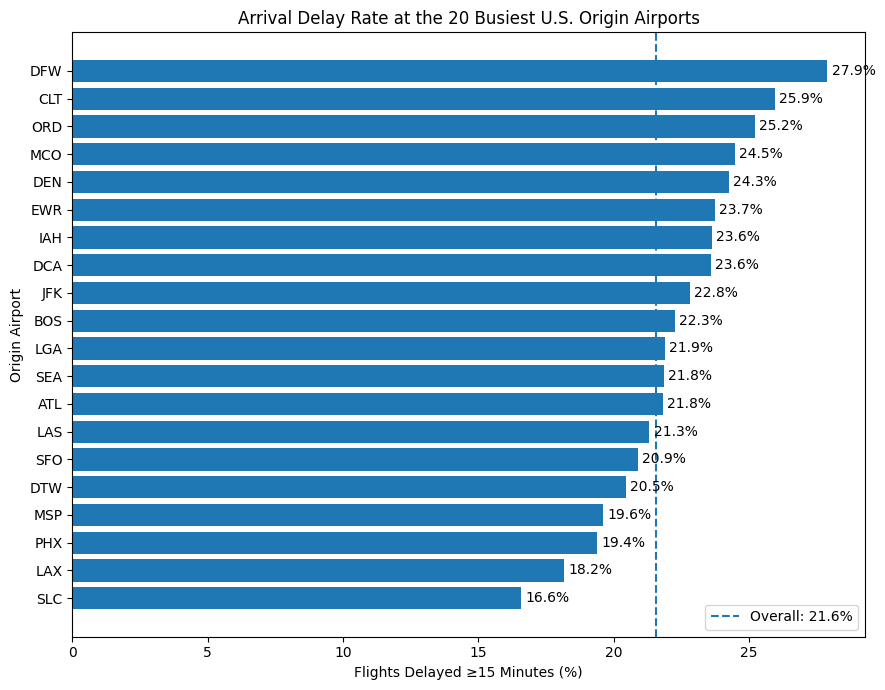

In [ ]:
overall_delay_rate = completed_flights["ArrDel15"].mean() * 100

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(
    top_airports["Origin"],
    top_airports["delay_rate"]
)

ax.axvline(
    overall_delay_rate,
    linestyle="--",
    linewidth=1.5,
    label=f"Overall: {overall_delay_rate:.1f}%"
)

ax.set_title("Arrival Delay Rate at the 20 Busiest U.S. Origin Airports")
ax.set_xlabel("Flights Delayed ≥15 Minutes (%)")
ax.set_ylabel("Origin Airport")

ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.legend()

plt.tight_layout()
plt.show()

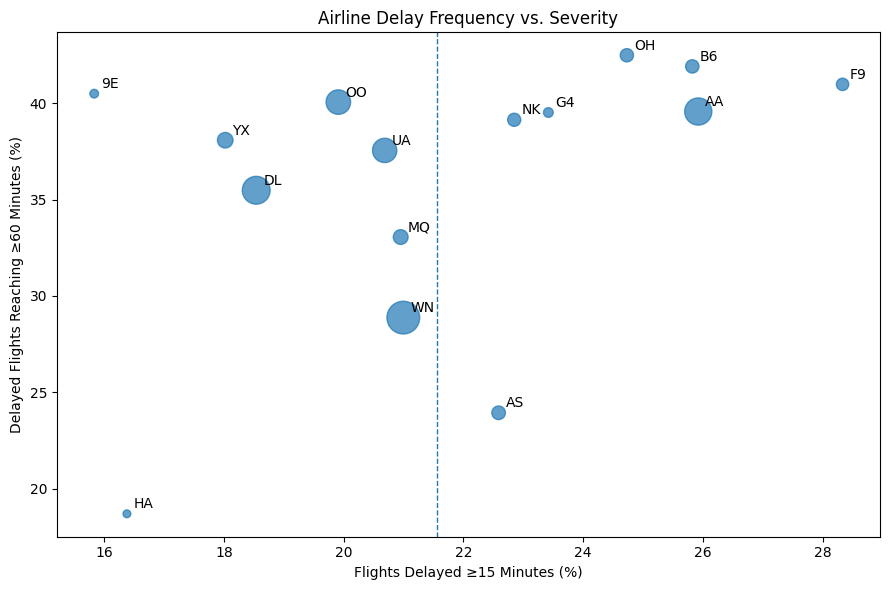

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    airline_delay["delay_rate"],
    airline_delay["severe_given_delayed"],
    s=airline_delay["flights"] / 5000,
    alpha=0.7
)

for _, row in airline_delay.iterrows():
    ax.annotate(
        row["Reporting_Airline"],
        (row["delay_rate"], row["severe_given_delayed"]),
        xytext=(5, 4),
        textcoords="offset points"
    )

ax.axvline(
    completed_flights["ArrDel15"].mean() * 100,
    linestyle="--",
    linewidth=1
)

ax.set_title("Airline Delay Frequency vs. Severity")
ax.set_xlabel("Flights Delayed ≥15 Minutes (%)")
ax.set_ylabel("Delayed Flights Reaching ≥60 Minutes (%)")

plt.tight_layout()
plt.show()

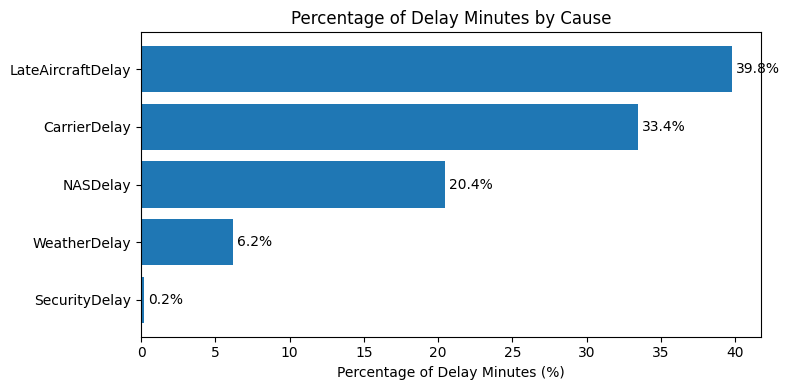

In [ ]:
cause_summary["pct_of_delay_minutes"] = (
    cause_summary["total_delay_minutes"]
    / cause_summary["total_delay_minutes"].sum()
    * 100
)

cause_plot = (
    cause_summary["pct_of_delay_minutes"]
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    cause_plot.index,
    cause_plot.values
)

ax.set_title("Percentage of Delay Minutes by Cause")
ax.set_xlabel("Percentage of Delay Minutes (%)")
ax.set_ylabel("")

ax.bar_label(bars, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()

## 5. Validation and modeling choices

### Time split

I use a forward-in-time split so future operating patterns do not leak into training:

- **Train:** Jan-Dec 2024
- **Validation:** Jan-Jun 2025
- **Final test:** Jul-Dec 2025

### Metrics

**PR-AUC** is the main metric because delayed flights are the minority class and the goal is to identify high-risk flights. ROC-AUC is also reported.

### Categorical features

Categorical variables are one-hot encoded. `Route` has many categories and was tested separately. It added almost no value, so it was removed.

### Scaling

Numeric features are standardized for logistic regression because it uses L2 regularization. XGBoost does not require scaling.

In [ ]:
# Modeling population and temporal split
model_df = completed_flights[
    completed_flights["CRSElapsedTime"].notna()
    & (completed_flights["CRSElapsedTime"] > 0)
].copy()

train_df = model_df[model_df["FlightDate"].between("2024-01-01", "2024-12-31")].copy()
val_df   = model_df[model_df["FlightDate"].between("2025-01-01", "2025-06-30")].copy()
test_df  = model_df[model_df["FlightDate"].between("2025-07-01", "2025-12-31")].copy()

## 6. Inbound aircraft

EDA showed that late inbound aircraft are an important source of delay, especially later in the day.

For each aircraft, I link the previous flight only when its destination matches the current flight's origin. At T-2h, the aircraft is placed into one of six states:

1. `Already arrived`
2. `Expected already - not arrived`
3. `Not expected - tight buffer`
4. `Not expected - slightly tight`
5. `Not expected - normal buffer`
6. `No valid inbound`

For aircraft that have not yet arrived, turnaround is compared with the airline's typical turnaround time calculated from **2024 training data only**.

In [ ]:
risk_summary = (
    model_df
    .groupby("inbound_risk_state")
    .agg(
        flights=("ArrDel15", "size"),
        delay_rate=("ArrDel15", "mean")
    )
    .reset_index()
)

risk_summary["delay_rate"] *= 100

risk_summary

,inbound_risk_state,flights,delay_rate
0,Already arrived,3938012,13.94
1,Expected already - not arrived,157813,43.45
2,No valid inbound,297656,46.01
3,Not expected - normal buffer,4667847,20.49
4,Not expected - slightly tight,4058331,23.48
5,Not expected - tight buffer,725071,44.20


### Leakage audit

Actual previous-arrival information is used only when that arrival occurs before T−2h. For `Expected already - not arrived`, scheduled arrival must be before the cutoff while actual arrival is after it. The audit below returns zero violations.

In [ ]:
# Already-arrived flights should NEVER have arrival after cutoff
(
    model_df.loc[
        model_df["inbound_risk_state"] == "Already arrived",
        "prev_actual_arr_local"
    ]
    > model_df.loc[
        model_df["inbound_risk_state"] == "Already arrived",
        "prediction_time"
    ]
).sum()

np.int64(0)

In [ ]:
# "Expected already - not arrived":
# scheduled arrival <= cutoff, but actual arrival > cutoff
check = model_df[
    model_df["inbound_risk_state"] ==
    "Expected already - not arrived"
]

print(
    "Scheduled after cutoff:",
    (check["prev_sched_arr_local"] > check["prediction_time"]).sum()
)

print(
    "Actual arrived by cutoff:",
    (check["prev_actual_arr_local"] <= check["prediction_time"]).sum()
)

Scheduled after cutoff: 0
Actual arrived by cutoff: 0


## 7. Aircraft metadata

FAA tail-number metadata are joined using N-number. Aircraft model is one-hot encoded; age and seat count are numeric. Model cardinality is only 100, so collapsing models would discard information without solving a meaningful dimensionality problem.

In [ ]:
print(
    "FAA aircraft match rate:",
    model_df["MFR"].notna().mean()
)

print(
    "Manufacture year coverage:",
    model_df["YEAR MFR"].notna().mean()
)

print(
    "Seat coverage:",
    model_df["NO-SEATS"].notna().mean()
)

print(
    "Weight coverage:",
    model_df["AC-WEIGHT"].notna().mean()
)

FAA aircraft match rate: 0.9737804926495497
Manufacture year coverage: 0.9472552371913356
Seat coverage: 0.9737804926495497
Weight coverage: 0.9737804926495497


In [ ]:
model_df["YEAR MFR"] = pd.to_numeric(
    model_df["YEAR MFR"], errors="coerce"
)

model_df["NO-SEATS"] = pd.to_numeric(
    model_df["NO-SEATS"], errors="coerce"
)

model_df["aircraft_age"] = (
    model_df["FlightDate"].dt.year
    - model_df["YEAR MFR"]
)

model_df[
    ["aircraft_age", "NO-SEATS"]
].describe(
    percentiles=[.01, .05, .25, .50, .75, .95, .99]
)

,aircraft_age,NO-SEATS
count,"13,114,493.00","13,481,728.00"
mean,12.66,158.67
std,8.13,72.21
min,0.00,4.00
1%,0.00,48.00
5%,1.00,55.00
25%,6.00,95.00
50%,11.00,162.00
75%,20.00,190.00
95%,26.00,330.00


## 8. Weather

Recent origin weather is joined using the latest observation available **at or before T-2h**. The join looks backward only and requires the weather observation to be no more than two hours old.

IEM station IDs were mapped to BTS airport codes where needed. Most stations match directly (for example, `JFK` and `ATL`), while some use ICAO codes such as `PHNL → HNL`, `PANC → ANC`, and `TJSJ → SJU`.

Weather coverage is about **99.8-99.9%**, and the median matched observation is about **25 minutes old**.

Actual destination weather at arrival is not used because it would be future information. A future version could use destination weather forecasts that were available at T-2h.

## 9. Validation results

| Model / features | ROC-AUC | PR-AUC |
|---|---:|---:|
| Logistic regression, schedule only | 0.6384 | 0.3178 |
| XGBoost, schedule only | 0.6433 | 0.3218 |
| XGBoost + route | 0.6433 | 0.3224 |
| + inbound aircraft state | 0.6784 | 0.3972 |
| + aircraft information | 0.6803 | 0.4032 |
| + weather | **0.7369** | **0.4807** |

Changing from logistic regression to XGBoost gave only a small improvement. Route also added little. The larger gains came from adding better information about the operating state of the flight.

### Risk ranking

| Risk decile | Actual delay rate | Avg. predicted risk |
|---:|---:|---:|
| 1 - lowest | 5.47% | 6.40% |
| 2 | 8.35% | 9.58% |
| 3 | 10.73% | 11.99% |
| 4 | 13.18% | 14.39% |
| 5 | 15.91% | 17.01% |
| 6 | 19.03% | 19.96% |
| 7 | 22.73% | 23.50% |
| 8 | 28.16% | 28.12% |
| 9 | 36.64% | 35.21% |
| 10 - highest | **58.75%** | **55.10%** |

The model clearly separates low- and high-risk flights, which supports using it as a ranking tool for operations.

In [ ]:
# Correct weather-model ablation
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

categorical_weather = [
    "Reporting_Airline", "Origin", "Dest", "DepTimeBlk",
    "inbound_risk_state", "MODEL", "skyc1"
]

numeric_weather = [
    "Month", "DayOfWeek", "Distance", "CRSElapsedTime",
    "aircraft_age", "NO-SEATS",
    "tmpf", "relh", "sknt", "gust", "p01i", "vsby", "skyl1",
    "gust_reported", "weather_event",
    "wx_thunderstorm", "wx_fog", "wx_snow", "wx_rain", "wx_freezing"
]

weather_features = categorical_weather + numeric_weather

train_weather = model_weather[
    model_weather["FlightDate"].between("2024-01-01", "2024-12-31")
].copy()
val_weather = model_weather[
    model_weather["FlightDate"].between("2025-01-01", "2025-06-30")
].copy()
test_weather = model_weather[
    model_weather["FlightDate"].between("2025-07-01", "2025-12-31")
].copy()

X_train_weather = train_weather[weather_features]
y_train_weather = train_weather["ArrDel15"].astype(int)
X_val_weather = val_weather[weather_features]
y_val_weather = val_weather["ArrDel15"].astype(int)

weather_preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_weather),
    ("num", SimpleImputer(strategy="median"), numeric_weather),
])

xgb_weather = Pipeline([
    ("preprocessor", weather_preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_weather.fit(X_train_weather, y_train_weather)
val_prob_weather = xgb_weather.predict_proba(X_val_weather)[:, 1]

print(f"Validation ROC-AUC: {roc_auc_score(y_val_weather, val_prob_weather):.4f}")
print(f"Validation PR-AUC:  {average_precision_score(y_val_weather, val_prob_weather):.4f}")

### Operational evaluation

For an operations team, the useful question is not only whether the model has a good AUC, but whether the highest-risk flights are meaningfully concentrated with delays.

The validation deciles show a clear risk gradient: the actual delay rate rises from **5.47%** in the lowest-risk decile to **58.75%** in the highest-risk decile.

Precision/Recall@K is also calculated below. It shows the trade-off when the airline can only focus on a limited share of flights.

In [ ]:
def precision_recall_at_k(y_true, y_score, k):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = max(1, int(len(y_true) * k))
    idx = np.argsort(y_score)[::-1][:n]
    y_top = y_true[idx]
    return y_top.mean(), y_top.sum() / y_true.sum()

for k in [0.01, 0.05, 0.10, 0.20]:
    p, r = precision_recall_at_k(y_val_weather, val_prob_weather, k)
    print(f"Top {k:.0%}: Precision={p:.2%} | Recall={r:.2%}")

## 10. Final test results

Jul-Dec 2025 was kept untouched while the feature set and model were selected using the training and validation periods. After the model was finalized, it was evaluated once on this held-out period.

| Metric | Validation | Final test |
|---|---:|---:|
| ROC-AUC | 0.7369 | **0.7417** |
| PR-AUC | 0.4807 | **0.4941** |

| Flights targeted | Precision | Recall |
|---|---:|---:|
| Top 1% | **86.96%** | 3.83% |
| Top 5% | **70.18%** | 15.45% |
| Top 10% | **60.11%** | 26.47% |
| Top 20% | **49.11%** | 43.25% |

Performance remained similar to validation, which is reassuring for generalization to later flights.

If operations can review only the highest-risk **10%** of flights, about **60%** of those flights are actually delayed, and this group captures about **26%** of all delayed flights.

In [ ]:
X_test_weather = test_weather[weather_features]
y_test_weather = test_weather["ArrDel15"].astype(int)
test_prob = xgb_weather.predict_proba(X_test_weather)[:, 1]

print(f"Test ROC-AUC: {roc_auc_score(y_test_weather, test_prob):.4f}")
print(f"Test PR-AUC:  {average_precision_score(y_test_weather, test_prob):.4f}")

for k in [0.01, 0.05, 0.10, 0.20]:
    p, r = precision_recall_at_k(y_test_weather, test_prob, k)
    print(f"Top {k:.0%}: Precision={p:.2%} | Recall={r:.2%}")

## 11. Recommendations

Use the model as a **risk ranking at T-2h** so the airline can focus attention on the flights most likely to be delayed.

Next steps:
- model cancellations and diversions separately;
- add destination weather forecasts available at T-2h;
- test airport congestion and more live operational information;
- monitor model performance and weather coverage over time.

A passenger-facing use case would need a separate evaluation. If probabilities are shown directly to passengers, I would check probability calibration and use a more conservative alert threshold to reduce false alerts.

## How to read the notebook

The notebook is organized as a report: problem framing → EDA → feature design → validation → final test. Large intermediate datasets are stored outside the notebook because the raw BTS and weather files contain millions of rows. The repository should include the data-preparation/modeling code or clear instructions for rebuilding those processed files from the listed public sources.


## Reproducibility note

Raw BTS, FAA and IEM files are not embedded because of their size. The analysis uses repo-relative `data/raw/` and `data/processed/` paths. Weather is joined month-by-month to avoid holding several multi-million-row sorted copies in memory.